# TFT Training — Cáceres Solar Forecast

This notebook trains a Temporal Fusion Transformer (TFT) on the preprocessed Cáceres solar
generation dataset. Hyperparameters are tuned using Optuna with a TPE sampler.

All hyperparameter selection uses validation data only.
The test set is evaluated in a separate notebook (`tft_evaluation.ipynb`) exactly once.

**Pipeline steps:**

| # | Step | Purpose |
|---|---|---|
| 0 | Imports & setup | Libraries, GPU detection, random seed |
| 1 | Configuration | Sequence lengths, feature lists, denorm params |
| 2 | Data loading | Load CSVs, add time_idx and group_id |
| 3 | TimeSeriesDataSet construction | Disable internal scaling, classify features |
| 4 | Learning rate finder | Establish LR range before tuning |
| 5 | Hyperparameter tuning | Optuna TPE, 25 trials, 6 hyperparameters |
| 6 | Final model training | Best HPs, early stopping, checkpointing |
| 7 | Validation evaluation | Denormalized metrics (RMSE, MAE, R²) |
| 8 | Save artifacts | Model, study, metrics, predictions |

## Step 0 — Imports & setup

In [1]:
import os, json, warnings, pickle
import numpy as np
import numpy._core.multiarray
import pandas as pd
import matplotlib.pyplot as plt

import torch
import lightning.pytorch as pl
from lightning.pytorch.callbacks import EarlyStopping, LearningRateMonitor, ModelCheckpoint
from lightning.pytorch.tuner import Tuner

from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer
from pytorch_forecasting.metrics import QuantileLoss, MAE, RMSE
from pytorch_forecasting.data.encoders import TorchNormalizer

import optuna
from optuna.samplers import TPESampler

# Restore pre-PyTorch-2.6 torch.load behavior (weights_only=False by default)
# Needed because Lightning's LR finder and checkpoint restore store pytorch-forecasting
# objects that aren't in the safe globals allowlist. Safe here — we only load our own checkpoints.
import functools
_orig_torch_load = torch.load
@functools.wraps(_orig_torch_load)
def _patched_torch_load(*args, **kwargs):
    if kwargs.get('weights_only') is None:
        kwargs['weights_only'] = False
    return _orig_torch_load(*args, **kwargs)
torch.load = _patched_torch_load

warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
pl.seed_everything(42)

print(f"PyTorch {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

/home/tzf/anaconda3/envs/mlvu/lib/python3.12/site-packages/pytorch_forecasting/models/base/_base_model.py:30: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm
Seed set to 42


PyTorch 2.10.0+cu128
CUDA available: True
GPU: NVIDIA GeForce RTX 5070 Ti


## Step 1 — Configuration

In [2]:
# ── Paths ──
DATA_DIR  = os.path.join(os.getcwd(), 'data')
MODEL_DIR = os.path.join(os.getcwd(), 'models')
os.makedirs(MODEL_DIR, exist_ok=True)

# ── Sequence lengths ──
MAX_ENCODER_LENGTH    = 168   # 7 days of hourly history
MAX_PREDICTION_LENGTH = 24    # 1-day-ahead forecast

# ── Feature classification ──
KNOWN_FUTURE = [
    'hour_sin', 'hour_cos', 'month_sin', 'month_cos',
    'doy_sin', 'doy_cos', 'solar_zenith', 'solar_azimuth', 'clearsky_ghi',
]
OBSERVED = [
    'dewpoint_2m_C', 'temperature_2m_C', 'surface_pressure_hPa',
    'total_precip_mm', 'ssrd_wm2', 'strd_wm2', 'kt', 'dewpoint_depression_C',
]
TARGET = 'pv_generation_mwh'

# ── Denormalization parameters ──
with open(os.path.join(DATA_DIR, 'preprocessing_params.json')) as f:
    pp = json.load(f)
TARGET_MEAN = pp['target_mean']
TARGET_STD  = pp['target_std']

print(f"Encoder: {MAX_ENCODER_LENGTH}h ({MAX_ENCODER_LENGTH//24}d)")
print(f"Prediction: {MAX_PREDICTION_LENGTH}h")
print(f"Known future features: {len(KNOWN_FUTURE)}")
print(f"Observed features: {len(OBSERVED)}")
print(f"Target denorm: z * {TARGET_STD:.4f} + {TARGET_MEAN:.4f}")

Encoder: 168h (7d)
Prediction: 24h
Known future features: 9
Observed features: 8
Target denorm: z * 739.4788 + 554.9327


## Step 2 — Load data & prepare for TimeSeriesDataSet

In [3]:
# ── Load CSVs ──
train_df = pd.read_csv(os.path.join(DATA_DIR, 'train_processed.csv'),
                        parse_dates=['datetime_utc'], index_col='datetime_utc')
val_df   = pd.read_csv(os.path.join(DATA_DIR, 'val_processed.csv'),
                        parse_dates=['datetime_utc'], index_col='datetime_utc')

print(f"Train: {len(train_df):,} rows  {train_df.index[0]} -> {train_df.index[-1]}")
print(f"Val:   {len(val_df):,} rows   {val_df.index[0]} -> {val_df.index[-1]}")

# ── Verify no NaN ──
assert train_df.isna().sum().sum() == 0, "NaN in training data"
assert val_df.isna().sum().sum() == 0, "NaN in validation data"

# ── Add time_idx: continuous integer across both splits ──
train_df = train_df.reset_index()
val_df   = val_df.reset_index()

train_df['time_idx'] = np.arange(len(train_df))
val_df['time_idx']   = np.arange(len(train_df), len(train_df) + len(val_df))

# ── Add constant group_id (single time series) ──
train_df['group_id'] = '0'
val_df['group_id']   = '0'

# ── Verify continuity ──
assert train_df['time_idx'].iloc[-1] + 1 == val_df['time_idx'].iloc[0], \
    "time_idx not continuous across train/val boundary"

print(f"\ntime_idx range — train: [0, {train_df['time_idx'].max()}], "
      f"val: [{val_df['time_idx'].min()}, {val_df['time_idx'].max()}]")
print(f"Columns: {list(train_df.columns)}")

Train: 17,544 rows  2023-01-01 00:00:00 -> 2024-12-31 23:00:00
Val:   4,344 rows   2025-01-01 00:00:00 -> 2025-06-30 23:00:00

time_idx range — train: [0, 17543], val: [17544, 21887]
Columns: ['datetime_utc', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'doy_sin', 'doy_cos', 'solar_zenith', 'solar_azimuth', 'clearsky_ghi', 'dewpoint_2m_C', 'temperature_2m_C', 'surface_pressure_hPa', 'total_precip_mm', 'ssrd_wm2', 'strd_wm2', 'kt', 'dewpoint_depression_C', 'pv_generation_mwh', 'time_idx', 'group_id']


## Step 3 — Construct TimeSeriesDataSet

The preprocessed data is already z-score standardized (train-set statistics applied to all splits).
`TimeSeriesDataSet` normally applies its own per-window normalization — we disable this by setting
`target_normalizer=None` and passing no scalers, to avoid double-normalization.

In [4]:
# ── Training dataset ──
training_dataset = TimeSeriesDataSet(
    train_df,
    time_idx='time_idx',
    target=TARGET,
    group_ids=['group_id'],

    max_encoder_length=MAX_ENCODER_LENGTH,
    max_prediction_length=MAX_PREDICTION_LENGTH,
    min_encoder_length=MAX_ENCODER_LENGTH,

    time_varying_known_reals=KNOWN_FUTURE,
    time_varying_unknown_reals=OBSERVED,

    target_normalizer=None,
    scalers={col: None for col in KNOWN_FUTURE + OBSERVED},

    add_relative_time_idx=True,
    add_encoder_length=True,
    allow_missing_timesteps=False,
)

print(f"Training dataset: {len(training_dataset)} samples")
print(f"Encoder length: {training_dataset.max_encoder_length}")
print(f"Prediction length: {training_dataset.max_prediction_length}")

Training dataset: 17353 samples
Encoder length: 168
Prediction length: 24


In [ ]:
# ── Validation dataset ──
# The validation encoder needs context from the training set tail
val_with_context = pd.concat([
    train_df.iloc[-MAX_ENCODER_LENGTH:],
    val_df
])

val_dataset = TimeSeriesDataSet.from_dataset(
    training_dataset,
    val_with_context,
    min_prediction_idx=val_df['time_idx'].min(),
    stop_randomization=True,
)

print(f"Validation dataset: {len(val_dataset)} samples")

Validation dataset: 1 samples


In [6]:
# ── DataLoaders ──
BATCH_SIZE = 64

train_dataloader = training_dataset.to_dataloader(
    train=True, batch_size=BATCH_SIZE, num_workers=2
)
val_dataloader = val_dataset.to_dataloader(
    train=False, batch_size=BATCH_SIZE, num_workers=2
)

# Sanity check: inspect one batch
x, y = next(iter(train_dataloader))
print(f"Batch shapes:")
print(f"  Encoder cont. inputs: {x['encoder_cont'].shape}")
print(f"  Decoder cont. inputs: {x['decoder_cont'].shape}")
print(f"  Target:               {y[0].shape}")

Batch shapes:
  Encoder cont. inputs: torch.Size([64, 168, 19])
  Decoder cont. inputs: torch.Size([64, 24, 19])
  Target:               torch.Size([64, 24])


## Step 4 — Learning rate finder

Run Lightning's LR finder to establish a reasonable learning rate range before HP tuning.
This prevents wasting Optuna trials on suboptimal LR regions.

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
You are using a CUDA device ('NVIDIA GeForce RTX 5070 Ti') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
2026-03-09 16:32:05.589442: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly 

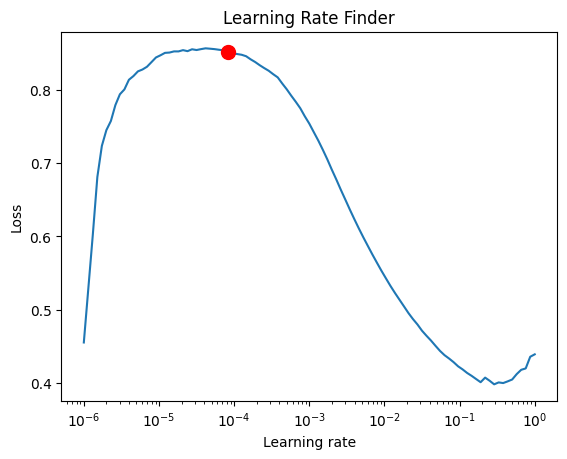

Suggested LR: 0.000083


In [7]:
# Quick model with default HPs for LR finding
tft_tmp = TemporalFusionTransformer.from_dataset(
    training_dataset,
    learning_rate=0.001,
    hidden_size=32,
    attention_head_size=2,
    dropout=0.1,
    hidden_continuous_size=16,
    loss=QuantileLoss(),
    optimizer='adam',
)

trainer_tmp = pl.Trainer(
    accelerator='auto',
    gradient_clip_val=0.1,
    max_epochs=3,
)

tuner = Tuner(trainer_tmp)
lr_finder = tuner.lr_find(
    tft_tmp,
    train_dataloaders=train_dataloader,
    val_dataloaders=val_dataloader,
    min_lr=1e-6,
    max_lr=1.0,
    num_training=100,
)

fig = lr_finder.plot(suggest=True)
plt.title("Learning Rate Finder")
plt.show()

suggested_lr = lr_finder.suggestion()
print(f"Suggested LR: {suggested_lr:.6f}")

del tft_tmp, trainer_tmp
torch.cuda.empty_cache()

## Step 5 — Hyperparameter tuning (Optuna, TPE, 25 trials)

Following the reference paper's approach (NNI with TPE) but using Optuna's TPE sampler
for simpler integration with pytorch-forecasting.

| Hyperparameter | Search Space | Rationale |
|---|---|---|
| `hidden_size` | {16, 32, 64, 128} | Model capacity; 128 already large for 17k samples |
| `lstm_layers` | {1, 2} | Temporal processing depth |
| `attention_head_size` | {1, 2, 4} | Multi-head interpretable attention |
| `dropout` | Uniform(0.1, 0.4) | Primary regularization lever |
| `hidden_continuous_size` | {8, 16, 32} | Continuous variable processing width |
| `learning_rate` | LogUniform(1e-4, 1e-2) | Guided by LR finder |

Per-trial: max 20 epochs, early stopping patience 3 on val_loss.

In [8]:
def optuna_objective(trial):
    """Single Optuna trial: sample HPs, train TFT, return val_loss."""

    # ── Sample hyperparameters ──
    hidden_size            = trial.suggest_categorical('hidden_size', [16, 32, 64, 128])
    lstm_layers            = trial.suggest_int('lstm_layers', 1, 2)
    attention_head_size    = trial.suggest_categorical('attention_head_size', [1, 2, 4])
    dropout                = trial.suggest_float('dropout', 0.1, 0.4)
    hidden_continuous_size = trial.suggest_categorical('hidden_continuous_size', [8, 16, 32])
    learning_rate          = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)

    # ── Create model ──
    tft = TemporalFusionTransformer.from_dataset(
        training_dataset,
        hidden_size=hidden_size,
        lstm_layers=lstm_layers,
        attention_head_size=attention_head_size,
        dropout=dropout,
        hidden_continuous_size=hidden_continuous_size,
        learning_rate=learning_rate,
        loss=QuantileLoss(),
        optimizer='adam',
        reduce_on_plateau_patience=3,
        output_size=7,
    )

    # ── Trainer (lightweight for tuning) ──
    trainer = pl.Trainer(
        max_epochs=10,  # 20 was gonna take way too long
        accelerator='auto',
        gradient_clip_val=0.1,
        callbacks=[
            EarlyStopping(monitor='val_loss', patience=3, mode='min', verbose=False),
        ],
        enable_model_summary=False,
        enable_progress_bar=False,
        enable_checkpointing=False,
        logger=False,
    )

    try:
        trainer.fit(tft, train_dataloaders=train_dataloader,
                    val_dataloaders=val_dataloader)
        val_loss = trainer.callback_metrics['val_loss'].item()
    except Exception as e:
        print(f"Trial {trial.number} failed: {e}")
        val_loss = float('inf')
    finally:
        torch.cuda.empty_cache()

    return val_loss

In [9]:
study = optuna.create_study(
    direction='minimize',
    sampler=TPESampler(seed=42),
    study_name='tft_caceres_hp_tuning',
)

study.optimize(
    optuna_objective,
    n_trials=15,    # 25 was also unnecessarily long for this
    show_progress_bar=True,
    gc_after_trial=True,
)

print(f"\nBest trial: #{study.best_trial.number}")
print(f"Best val_loss: {study.best_value:.6f}")
print(f"Best params:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

[I 2026-03-09 16:32:18,370] A new study created in memory with name: tft_caceres_hp_tuning
  0%|          | 0/15 [00:00<?, ?it/s]GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Best trial: 0. Best value: 0.114145:   7%|▋         | 1/15 [00:28<06:33, 28.09s/it]GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


[I 2026-03-09 16:32:46,288] Trial 0 finished with value: 0.11414477974176407 and parameters: {'hidden_size': 32, 'lstm_layers': 1, 'attention_head_size': 4, 'dropout': 0.2803345035229627, 'hidden_continuous_size': 32, 'learning_rate': 0.004622589001020831}. Best is trial 0 with value: 0.11414477974176407.


Best trial: 0. Best value: 0.114145:  13%|█▎        | 2/15 [05:09<38:24, 177.25s/it]GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


[I 2026-03-09 16:37:27,955] Trial 1 finished with value: 0.16531944274902344 and parameters: {'hidden_size': 128, 'lstm_layers': 2, 'attention_head_size': 4, 'dropout': 0.14184815819561256, 'hidden_continuous_size': 32, 'learning_rate': 0.0037183641805732083}. Best is trial 0 with value: 0.11414477974176407.


Best trial: 0. Best value: 0.114145:  20%|██        | 3/15 [08:26<37:13, 186.14s/it]GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


...

[I 2026-03-09 17:13:08,655] Trial 12 finished with value: 0.14027726650238037 and parameters: {'hidden_size': 16, 'lstm_layers': 2, 'attention_head_size': 2, 'dropout': 0.2681208265809009, 'hidden_continuous_size': 32, 'learning_rate': 0.001701714910025963}. Best is trial 4 with value: 0.09975685924291611.


`Trainer.fit` stopped: `max_epochs=10` reached.
Best trial: 4. Best value: 0.0997569:  93%|█████████▎| 14/15 [46:09<03:48, 228.99s/it]GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


[I 2026-03-09 17:18:27,957] Trial 13 finished with value: 0.14133571088314056 and parameters: {'hidden_size': 64, 'lstm_layers': 1, 'attention_head_size': 2, 'dropout': 0.25833366790900963, 'hidden_continuous_size': 16, 'learning_rate': 0.0004182742553970461}. Best is trial 4 with value: 0.09975685924291611.


Best trial: 4. Best value: 0.0997569: 100%|██████████| 15/15 [48:47<00:00, 195.19s/it]

[I 2026-03-09 17:21:06,043] Trial 14 finished with value: 0.10118758678436279 and parameters: {'hidden_size': 16, 'lstm_layers': 1, 'attention_head_size': 2, 'dropout': 0.177351390569862, 'hidden_continuous_size': 8, 'learning_rate': 0.009548472934188073}. Best is trial 4 with value: 0.09975685924291611.

Best trial: #4
Best val_loss: 0.099757
Best params:
  hidden_size: 16
  lstm_layers: 1
  attention_head_size: 4
  dropout: 0.21660318690684463
  hidden_continuous_size: 16
  learning_rate: 0.0003646439558980723


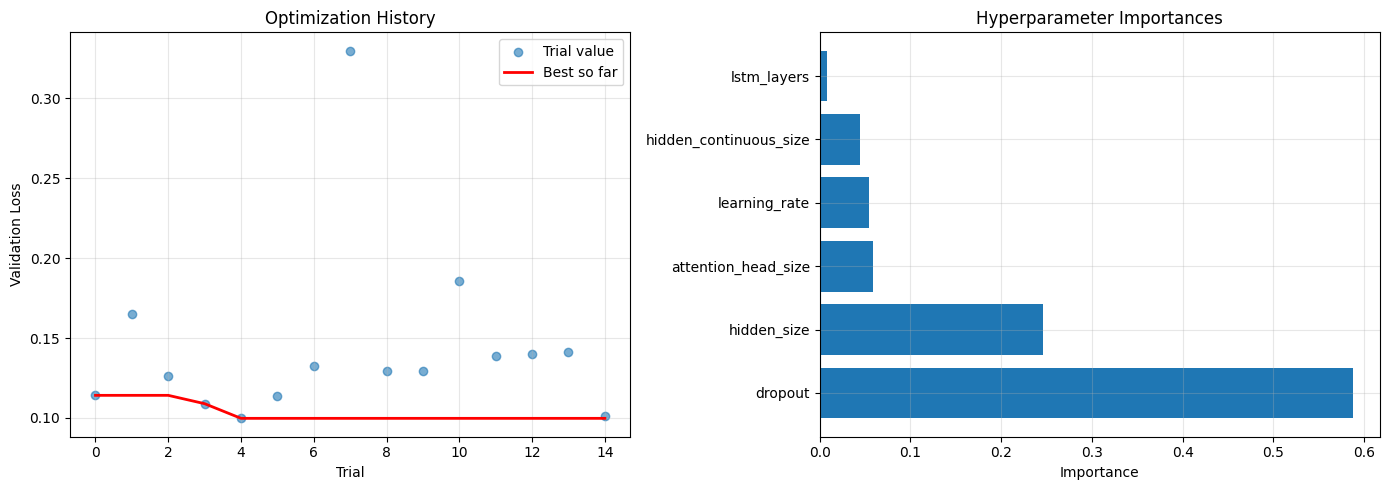

In [10]:
# ── Visualize the HP study ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Optimization history
trial_numbers = [t.number for t in study.trials if t.value is not None and t.value < float('inf')]
trial_values  = [t.value for t in study.trials if t.value is not None and t.value < float('inf')]
best_so_far   = np.minimum.accumulate(trial_values)

axes[0].scatter(trial_numbers, trial_values, alpha=0.6, label='Trial value')
axes[0].plot(trial_numbers, best_so_far, 'r-', linewidth=2, label='Best so far')
axes[0].set_xlabel('Trial')
axes[0].set_ylabel('Validation Loss')
axes[0].set_title('Optimization History')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Parameter importances (manual: use trial values)
param_names = list(study.best_params.keys())
importances = optuna.importance.get_param_importances(study)
axes[1].barh(list(importances.keys()), list(importances.values()))
axes[1].set_xlabel('Importance')
axes[1].set_title('Hyperparameter Importances')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Step 6 — Train final model with best HPs

Full training with the best hyperparameters from the Optuna study.
Longer training budget (max 75 epochs) with patience 10 and model checkpointing.

In [11]:
best = study.best_params

tft_final = TemporalFusionTransformer.from_dataset(
    training_dataset,
    hidden_size=best['hidden_size'],
    lstm_layers=best['lstm_layers'],
    attention_head_size=best['attention_head_size'],
    dropout=best['dropout'],
    hidden_continuous_size=best['hidden_continuous_size'],
    learning_rate=best['learning_rate'],
    loss=QuantileLoss(),
    optimizer='adam',
    reduce_on_plateau_patience=5,
    output_size=7,
)

print(f"Model parameters: {sum(p.numel() for p in tft_final.parameters()):,}")
print(f"Best HPs: {best}")

Model parameters: 54,943
Best HPs: {'hidden_size': 16, 'lstm_layers': 1, 'attention_head_size': 4, 'dropout': 0.21660318690684463, 'hidden_continuous_size': 16, 'learning_rate': 0.0003646439558980723}


In [12]:
checkpoint_callback = ModelCheckpoint(
    dirpath=MODEL_DIR,
    filename='tft_best',
    monitor='val_loss',
    mode='min',
    save_top_k=1,
)

trainer_final = pl.Trainer(
    max_epochs=75,
    accelerator='auto',
    gradient_clip_val=0.1,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=10, mode='min', verbose=True),
        checkpoint_callback,
        LearningRateMonitor(logging_interval='epoch'),
    ],
    log_every_n_steps=50,
)

trainer_final.fit(
    tft_final,
    train_dataloaders=train_dataloader,
    val_dataloaders=val_dataloader,
)

print(f"\nBest model saved to: {checkpoint_callback.best_model_path}")
print(f"Best val_loss: {checkpoint_callback.best_model_score:.6f}")

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ QuantileLoss                    │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │      0 │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │    608 │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │  1.2 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │ 26.6 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │ 13.7 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │  2.2 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │  2.2 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │    544 │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │     32 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │  1.4 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │    676 │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │    576 │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │    576 │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │    119 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 54.9 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 54.9 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 456                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Metric val_loss improved. New best score: 0.104
Metric val_loss improved by 0.012 >= min_delta = 0.0. New best score: 0.092
Monitored metric val_loss did not improve in the last 10 records. Best score: 0.092. Signaling Trainer to stop.



Best model saved to: /home/tzf/bachelor/MLVU/project/ML-solar-forecast/caceres_analysis/models/tft_best.ckpt
Best val_loss: 0.091934


In [13]:
# ── Plot training vs validation loss (generalization gap monitor) ──
train_losses = []
val_losses = []

# Extract from trainer's logged metrics
log_dir = trainer_final.logger.log_dir
metrics_file = os.path.join(log_dir, 'metrics.csv') if log_dir else None

if metrics_file and os.path.exists(metrics_file):
    metrics_df = pd.read_csv(metrics_file)
    # group by epoch and get last value per epoch
    if 'train_loss_epoch' in metrics_df.columns:
        train_loss_per_epoch = metrics_df.dropna(subset=['train_loss_epoch']).groupby('epoch')['train_loss_epoch'].last()
        val_loss_per_epoch = metrics_df.dropna(subset=['val_loss']).groupby('epoch')['val_loss'].last()

        fig, ax = plt.subplots(figsize=(10, 5))
        ax.plot(train_loss_per_epoch.index, train_loss_per_epoch.values, label='Train loss')
        ax.plot(val_loss_per_epoch.index, val_loss_per_epoch.values, label='Val loss')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Quantile Loss')
        ax.set_title('Training vs Validation Loss (generalization gap monitor)')
        ax.legend()
        ax.grid(True, alpha=0.3)
        plt.show()

        gap = val_loss_per_epoch.min() - train_loss_per_epoch.min()
        print(f"Generalization gap (val_min - train_min): {gap:.6f}")
    else:
        print("Training loss not logged per epoch. Check logger configuration.")
else:
    print("No metrics CSV found. Loss curves unavailable.")

No metrics CSV found. Loss curves unavailable.


## Step 7 — Validation evaluation

Generate predictions on the validation set and compute metrics on the original MWh scale.
This is the final validation — no further model changes after this point.

In [14]:
def denormalize(z_values):
    """Convert z-score normalized values back to original MWh scale."""
    return z_values * TARGET_STD + TARGET_MEAN

def compute_metrics(actual_mwh, predicted_mwh):
    """Compute RMSE, MAE, R² on original MWh scale."""
    residuals = actual_mwh - predicted_mwh
    mae  = np.abs(residuals).mean()
    rmse = np.sqrt((residuals ** 2).mean())
    ss_res = (residuals ** 2).sum()
    ss_tot = ((actual_mwh - actual_mwh.mean()) ** 2).sum()
    r2 = 1 - ss_res / ss_tot
    return {'MAE_MWh': float(mae), 'RMSE_MWh': float(rmse), 'R2': float(r2)}

In [17]:
# Load best checkpoint
best_model = TemporalFusionTransformer.load_from_checkpoint(
    checkpoint_callback.best_model_path
)
best_model.eval()

# Predict on validation set
val_predictions = best_model.predict(
    val_dataloader,
    mode='prediction',
    return_x=True,
    return_y=True,
)

val_raw = best_model.predict(
    val_dataloader,
    mode='raw',
    return_x=True,
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelC

In [18]:
# Extract predictions and actuals
pred_z   = val_predictions.output.cpu().numpy()
actual_z = val_predictions.y[0].cpu().numpy()

# Flatten across all windows and horizons
pred_z_flat   = pred_z.flatten()
actual_z_flat = actual_z.flatten()

# Denormalize
pred_mwh   = denormalize(pred_z_flat)
actual_mwh = denormalize(actual_z_flat)

# Clip negative predictions to 0 (solar generation cannot be negative)
pred_mwh = np.clip(pred_mwh, 0, None)

val_metrics = compute_metrics(actual_mwh, pred_mwh)
print("Validation Metrics (original MWh scale):")
for k, v in val_metrics.items():
    print(f"  {k}: {v:.4f}")
print(f"\nValidation quantile loss (normalized): {checkpoint_callback.best_model_score:.6f}")

Validation Metrics (original MWh scale):
  MAE_MWh: 131.0098
  RMSE_MWh: 204.0089
  R2: 0.9374

Validation quantile loss (normalized): 0.091934


/tmp/ipykernel_77104/3233380009.py:12: RuntimeWarning: divide by zero encountered in scalar divide
  r2 = 1 - ss_res / ss_tot


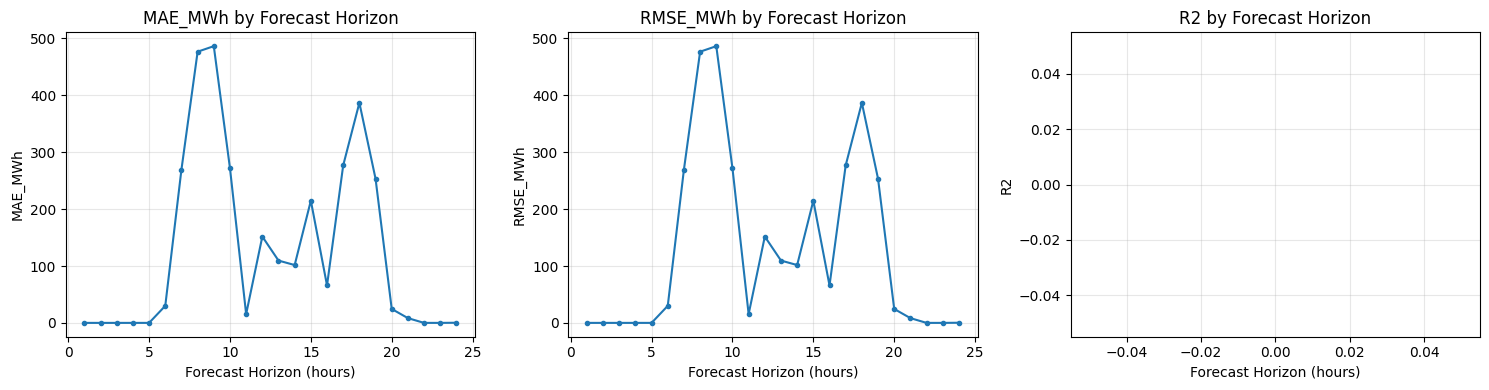

   MAE_MWh   RMSE_MWh   R2  horizon_h
  0.000061   0.000061 -inf          1
  0.000061   0.000061 -inf          2
  0.002014   0.002014 -inf          3
  0.001038   0.001038 -inf          4
  0.007996   0.007996 -inf          5
 29.971985  29.971985 -inf          6
269.613037 269.613037 -inf          7
476.750427 476.750427 -inf          8
486.483643 486.483643 -inf          9
271.901367 271.901367 -inf         10
 15.410645  15.410645 -inf         11
151.799561 151.799561 -inf         12
109.540771 109.540771 -inf         13
101.677002 101.677002 -inf         14
214.840820 214.840820 -inf         15
 65.815674  65.815674 -inf         16
276.908691 276.908691 -inf         17
386.894531 386.894531 -inf         18
253.479004 253.479004 -inf         19
 24.493805  24.493805 -inf         20
  8.385559   8.385559 -inf         21
  0.000061   0.000061 -inf         22
  0.001038   0.001038 -inf         23
  0.256714   0.256714 -inf         24


In [19]:
# ── Per-horizon metrics ──
horizon_metrics = []
for h in range(MAX_PREDICTION_LENGTH):
    pred_h   = denormalize(pred_z[:, h])
    actual_h = denormalize(actual_z[:, h])
    pred_h   = np.clip(pred_h, 0, None)
    m = compute_metrics(actual_h, pred_h)
    m['horizon_h'] = h + 1
    horizon_metrics.append(m)

horizon_df = pd.DataFrame(horizon_metrics)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metric in zip(axes, ['MAE_MWh', 'RMSE_MWh', 'R2']):
    ax.plot(horizon_df['horizon_h'], horizon_df[metric], marker='o', markersize=3)
    ax.set_xlabel('Forecast Horizon (hours)')
    ax.set_ylabel(metric)
    ax.set_title(f'{metric} by Forecast Horizon')
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(horizon_df.to_string(index=False))

## Step 8 — Save artifacts

In [ ]:
# 1. Optuna study (for later analysis / warm-starting)
with open(os.path.join(MODEL_DIR, 'hp_study.pkl'), 'wb') as f:
    pickle.dump(study, f)

# 2. Human-readable HP results
hp_results = {
    'best_trial': study.best_trial.number,
    'best_val_loss': study.best_value,
    'best_params': study.best_params,
    'n_trials': len(study.trials),
    'val_metrics_mwh': val_metrics,
    'sequence_config': {
        'max_encoder_length': MAX_ENCODER_LENGTH,
        'max_prediction_length': MAX_PREDICTION_LENGTH,
    },
    'training_config': {
        'batch_size': BATCH_SIZE,
        'max_epochs_final': 75,
        'early_stopping_patience': 10,
        'gradient_clip_val': 0.1,
        'optimizer': 'adam',
        'loss': 'QuantileLoss',
        'quantiles': [0.02, 0.1, 0.25, 0.5, 0.75, 0.9, 0.98],
    },
}

with open(os.path.join(MODEL_DIR, 'hp_study_results.json'), 'w') as f:
    json.dump(hp_results, f, indent=2)

# 3. Validation predictions
val_pred_df = pd.DataFrame({
    'actual_z': actual_z_flat,
    'predicted_z': pred_z_flat,
    'actual_mwh': actual_mwh,
    'predicted_mwh': pred_mwh,
})
val_pred_df.to_csv(os.path.join(MODEL_DIR, 'val_predictions.csv'), index=False)

print("Artifacts saved:")
for f_name in sorted(os.listdir(MODEL_DIR)):
    f_path = os.path.join(MODEL_DIR, f_name)
    if os.path.isfile(f_path):
        size_mb = os.path.getsize(f_path) / 1e6
        print(f"  {f_name}: {size_mb:.1f} MB")

In [ ]:
print("=" * 60)
print("TRAINING COMPLETE")
print("=" * 60)
print(f"\nBest hyperparameters:")
for k, v in best.items():
    print(f"  {k}: {v}")
print(f"\nValidation metrics (MWh scale):")
for k, v in val_metrics.items():
    print(f"  {k}: {v:.4f}")
print(f"\nModel checkpoint: {checkpoint_callback.best_model_path}")
print(f"\nNext step: run tft_evaluation.ipynb for test set evaluation.")